# 01 — Investment universe and data

**Workstream A** of the group project plan. This notebook is the front of the pipeline: it fixes the
universe, downloads the prices, builds the aligned panel and the return frames, and produces the two
tables and two figures that report section 2 (*Data*) is anchored on.

| Task | Output |
| --- | --- |
| A1 | `UNIVERSE` / `BENCHMARKS` — the single source of truth, imported by every later notebook |
| A2 | Raw price frame, extraction date recorded |
| A3 | Aligned adjusted-close panel on the NYSE calendar |
| A4 | **Table 1.1 — Data availability** |
| A5 | **Table 1.2 — Data quality** |
| A6 | Six return frames (daily/weekly/monthly × log/simple) |
| A7 | **Figure 1.1 — Asset correlation heatmap** |
| A8 | **Figure 1.2 — Cumulative growth of $1** |

Conventions come from [`docs/project-definitions.md`](../docs/project-definitions.md). Nothing is
written to disk — prices are pulled from Yahoo Finance on every run, so the extraction date printed in
A2 is the date that must be quoted throughout the report.

## Setup

In [1]:
import sys
from pathlib import Path

# The shared modules live at the repository root, one level above this notebook.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src import data, fmt, viz

viz.use_house_style()
np.random.seed(cfg.SEED)  # nothing here is random, but the seed is fixed everywhere

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

---

## A1 — The investable universe

Six assets, all quoted in USD on US venues, so the pipeline needs no currency conversion. Strategies
allocate **only** to these six. The S&P 500 is held outside the universe as an external reference and
is never allocated to.

`UNIVERSE` and `BENCHMARKS` are defined once, in `src/config.py`. Swapping a ticker is a one-line edit
there — nothing downstream hardcodes one.

In [2]:
universe = pd.DataFrame(cfg.UNIVERSE).T.rename_axis("Ticker")
universe.index.name = "Ticker"
display(universe[["name", "asset_class", "instrument"]].rename(
    columns={"name": "Name", "asset_class": "Asset class", "instrument": "Instrument"}
))

print("Fixed asset order:  ", " -> ".join(cfg.ASSET_ORDER))
print("Stylised facts on:  ", cfg.STYLISED_FACTS_TICKER)
print("Calendar defined by:", cfg.CALENDAR_TICKER)
print("Risk-free series:   ", cfg.RISK_FREE_TICKER)

,Name,Asset class,Instrument
Ticker,,,
GC=F,"Gold, COMEX continuous front-month",Commodity,Futures proxy
GOVT,iShares US Treasury Bond ETF,Government bonds,ETF
TSM,Taiwan Semiconductor Manufacturing,Equity -- semiconductors,ADR
VNQ,Vanguard Real Estate Index Fund ETF,Real estate / REITs,ETF
RNMBY,Rheinmetall AG,Equity -- defence,ADR
BTC-USD,Bitcoin,Cryptoasset,Spot proxy


Fixed asset order:   GC=F -> GOVT -> TSM -> VNQ -> RNMBY -> BTC-USD
Stylised facts on:   TSM
Calendar defined by: SPY
Risk-free series:    ^IRX


In [3]:
# The proxy labels the brief requires, carried on the universe itself so they
# cannot be forgotten in the prose.
for ticker, info in cfg.UNIVERSE.items():
    if info["proxy_for"]:
        print(f"PROXY  {ticker}: {info['proxy_for']}")

display(pd.DataFrame(cfg.BENCHMARKS).T.rename_axis("Ticker").rename(
    columns={"name": "Name", "investable": "Investable", "use": "Use"}
))

PROXY  GC=F: Spot gold exposure; investable counterpart GLD or IAU
PROXY  BTC-USD: Spot bitcoin; not investable via a US product before the Jan-2024 spot ETFs


,Name,Investable,Use
Ticker,,,
^GSPC,S&P 500 price index,False,Quoted when describing 'the market'; excludes ...
SPY,SPDR S&P 500 ETF Trust,True,Every performance comparison; also defines the...


---

## A2 — Download and extraction date

Full available history for the six assets, both benchmarks and the risk-free series, in one call.
`auto_adjust=True`, so prices are adjusted for splits and dividends — material for `GOVT` and `VNQ`,
whose total return is mostly income.

**The extraction date printed below must be quoted identically in every table and figure in the
report** (plan G2).

In [4]:
close, volume, extraction_date = data.download_raw()

print(f"Extraction date : {extraction_date.isoformat()}")
print(f"Source          : Yahoo Finance via yfinance, auto_adjust=True")
print(f"Tickers         : {', '.join(cfg.ALL_TICKERS)}")
print(f"Raw frame       : {close.shape[0]:,} dates x {close.shape[1]} tickers")
print(f"Earliest obs.   : {close.dropna(how='all').index[0].date()}")
print(f"Latest obs.     : {close.dropna(how='all').index[-1].date()}")

Extraction date : 2026-10-05
Source          : Yahoo Finance via yfinance, auto_adjust=True
Tickers         : GC=F, GOVT, TSM, VNQ, RNMBY, BTC-USD, ^GSPC, SPY, ^IRX
Raw frame       : 26,182 dates x 9 tickers
Earliest obs.   : 1927-12-30
Latest obs.     : 2026-10-05


---

## A3 — Calendar and alignment

The trading calendar is the set of dates `SPY` trades. Every series is reindexed onto it, which is what
drops `BTC-USD`'s weekend and holiday observations — they are discarded rather than aggregated into the
adjacent session, and the resulting understatement of bitcoin's risk is disclosed in the report.

Three rules, all from definitions §4:

- **Staggered entry.** Assets enter on their own first observation. Pre-entry cells stay `NaN` — never
  zero-filled, never back-filled.
- **Interior gaps** are forward-filled up to 3 sessions. Anything longer is reported, not patched.
- **Nothing is filled silently.** Every fill is counted and shown in Table 1.2.

In [5]:
panel = data.build_panel(close, volume, extraction_date, start=cfg.PANEL_START)

print(f"Panel period       : {panel.calendar[0].date()} to {panel.calendar[-1].date()}")
print(f"NYSE sessions      : {len(panel.calendar):,}")
print(f"Span               : {(panel.calendar[-1] - panel.calendar[0]).days / 365.25:.1f} years")
print(f"Six-asset intersection starts: {panel.full_panel_start.date()}"
      f"  ({(panel.calendar[-1] - panel.full_panel_start).days / 365.25:.1f} years)")
print()
print("Observations dropped as off-calendar:")
for ticker, n in panel.dropped_offcalendar.items():
    if n:
        print(f"  {ticker:<8} {n:>5,}")
print()
print("Sessions forward-filled (interior gaps, limit "
      f"{cfg.FFILL_LIMIT}):")
for ticker, n in panel.fills.items():
    if n:
        print(f"  {ticker:<8} {n:>5,}")

if panel.unpatched_gaps.empty:
    print("\nGaps longer than the fill limit: none.")
else:
    display(panel.unpatched_gaps)

Panel period       : 2011-10-03 to 2026-10-02
NYSE sessions      : 3,772
Span               : 15.0 years
Six-asset intersection starts: 2014-09-17  (12.0 years)

Observations dropped as off-calendar:
  GC=F         4
  BTC-USD  1,373

Sessions forward-filled (interior gaps, limit 3):
  GC=F         3

Gaps longer than the fill limit: none.


The panel spans **15 years**, as the brief requires. The six-asset intersection is only **12 years**,
because `BTC-USD` has no history before September 2014. Both numbers are disclosed in the report; the
sampler in workstream C handles the difference by drawing each window only from dates where every asset
*in that drawn subset* has data, so the short histories cost us windows rather than assets.

---

## A4 — Table 1.1, data availability

History and liquidity per asset, measured over each asset's **own full history** rather than the panel,
because the question this table answers is whether the asset clears the brief's 15-year minimum.

Median volume is measured over the panel period. It is in shares for the ETFs and ADRs, contracts for
`GC=F`, and USD for `BTC-USD` — the units are not comparable across rows, which is why the table reads
as an order-of-magnitude liquidity check rather than a ranking.

In [6]:
availability = data.availability_table(panel, cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK, "^GSPC"])

table_1_1 = fmt.style(availability, {
    "Years": lambda v: fmt.number(v, 1),
    "Obs./yr": lambda v: fmt.count(v),
    "Median volume": fmt.count,
})
# An index level's "volume" is the summed volume of its constituents, not a
# tradable quantity -- not applicable, so an em dash.
table_1_1.loc["^GSPC", "Median volume"] = fmt.NA

print("Table 1.1 - Data availability. Yahoo Finance, extracted "
      f"{panel.extraction_date.isoformat()}. Median volume over the panel period "
      f"{panel.calendar[0].date()} to {panel.calendar[-1].date()}.")
display(table_1_1)

Table 1.1 - Data availability. Yahoo Finance, extracted 2026-10-05. Median volume over the panel period 2011-10-03 to 2026-10-02.


,Name,Asset class,Instrument,First obs.,Years,Obs./yr,Median volume,Meets 15y
Ticker,,,,,,,,
GC=F,"Gold, COMEX continuous front-month",Commodity,Futures proxy,2000-08-30,26.1,251,198,Yes
GOVT,iShares US Treasury Bond ETF,Government bonds,ETF,2012-02-24,14.6,251,"2,651,700",No
TSM,Taiwan Semiconductor Manufacturing,Equity -- semiconductors,ADR,1997-10-09,29.0,251,"8,938,084",Yes
VNQ,Vanguard Real Estate Index Fund ETF,Real estate / REITs,ETF,2004-09-29,22.0,252,"3,208,250",Yes
RNMBY,Rheinmetall AG,Equity -- defence,ADR,2012-11-26,13.9,251,"1,500",No
BTC-USD,Bitcoin,Cryptoasset,Spot proxy,2014-09-17,12.0,365,"18,424,360,882",No
SPY,SPDR S&P 500 ETF Trust,Benchmark,ETF,1993-01-29,33.7,252,"62,700,100",Yes
^GSPC,S&P 500 price index,Benchmark,Index,1927-12-30,98.8,251,—,Yes


In [7]:
short = availability.loc[cfg.ASSET_ORDER].query(f"Years < {cfg.MIN_YEARS_REQUIRED}")
print(f"Assets short of the {cfg.MIN_YEARS_REQUIRED}-year minimum: {len(short)} of {len(cfg.ASSET_ORDER)}")
for ticker, row in short.iterrows():
    print(f"  {ticker:<8} {row['Years']:.1f} years (from {row['First obs.']})")

Assets short of the 15-year minimum: 3 of 6
  GOVT     14.6 years (from 2012-02-24)
  RNMBY    13.9 years (from 2012-11-26)
  BTC-USD  12.0 years (from 2014-09-17)


---

## A5 — Table 1.2, data quality

Missing and stale observations within the panel. `% zero-return days` is the staleness test: a price
that does not move is either a genuinely flat session or a price that was not refreshed, and a thinly
traded name produces many of the second kind. It is measured on the **final, filled** series, so the
handful of forward-filled sessions appear here as zero returns — that is the honest reading, since it
is the filled series the analysis consumes.

In [8]:
quality = data.quality_table(panel, cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK])

table_1_2 = fmt.style(quality, {
    "Obs.": fmt.count,
    "Missing obs.": fmt.count,
    "Longest gap (sessions)": fmt.count,
    "% zero-return days": lambda v: fmt.percent(v, 2),
})

print("Table 1.2 - Data quality. Panel period "
      f"{panel.calendar[0].date()} to {panel.calendar[-1].date()}, NYSE sessions. "
      "Zero-return share measured after the forward-fill.")
display(table_1_2)

Table 1.2 - Data quality. Panel period 2011-10-03 to 2026-10-02, NYSE sessions. Zero-return share measured after the forward-fill.


,Panel start,Obs.,Missing obs.,Longest gap (sessions),% zero-return days,Treatment applied
Ticker,,,,,,
GC=F,2011-10-03,"3,772",3,1,0.53,4 off-calendar obs. dropped; 3 session(s) forw...
GOVT,2012-02-24,"3,673",0,0,6.37,None required
TSM,2011-10-03,"3,772",0,0,1.01,None required
VNQ,2011-10-03,"3,772",0,0,0.50,None required
RNMBY,2012-11-26,"3,484",0,0,19.90,None required
BTC-USD,2014-09-17,"3,029",0,0,0.03,"1,373 off-calendar obs. dropped"
SPY,2011-10-03,"3,772",0,0,0.29,None required


In [9]:
# Reconciliation: Table 1.2's observation count must equal the sessions available
# to each asset since its entry, minus anything the fill limit could not reach.
for ticker in cfg.ASSET_ORDER:
    first = panel.prices_raw[ticker].first_valid_index()
    available = int((panel.calendar >= first).sum())
    reported = int(quality.loc[ticker, "Obs."])
    unfilled = int(quality.loc[ticker, "Missing obs."]) - panel.fills[ticker]
    assert reported == available - unfilled, ticker
    assert reported == int(panel.prices[ticker].notna().sum()), ticker
print("Table 1.1 and 1.2 reconcile with the panel for all six assets.")

Table 1.1 and 1.2 reconcile with the panel for all six assets.


**The RNMBY result is the one that matters.** Close to a fifth of its sessions show no price change at
all, against 0.3–1.0% for the liquid names. The ADR trades a median of 1,500 shares a day over the
panel, so its quoted close is frequently a stale print rather than a fresh transaction. Stale prices
bias measured volatility *downward* and measured correlation *toward zero*, which flatters any strategy
that sizes positions by inverse volatility. Workstream F tests directly whether `RNMBY` drives the
ranking.

`GOVT`'s 6.4% is a different story and not a problem: a short-duration Treasury ETF genuinely does
close unchanged on quiet days.

---

## A6 — Return frames

Six frames: daily, weekly and monthly, each in log and simple returns.

- **Log returns** — `ln(P_t) − ln(P_{t−1})` — for all stylised-facts analysis, because they aggregate by
  addition across time.
- **Simple returns** — for all portfolio compounding and performance statistics, because they aggregate
  by addition across *assets*, which is what a portfolio weight does.

Weekly and monthly log returns are the sum of the daily log returns in the period; the simple frames are
the equivalent compounded figure, `exp(sum) − 1`, so both kinds describe the same price moves. Weeks end
Friday, months on the last trading day. Periods before an asset's entry stay `NaN` rather than summing
to zero.

In [10]:
returns = data.build_returns(panel)

summary = pd.DataFrame(
    [
        {
            "Frequency": frequency,
            "Kind": kind,
            "Periods": len(returns[(frequency, kind)]),
            "Complete rows (all six)": int(returns[(frequency, kind)][cfg.ASSET_ORDER].dropna().shape[0]),
            "First": returns[(frequency, kind)].dropna(how="all").index[0].date(),
            "Last": returns[(frequency, kind)].dropna(how="all").index[-1].date(),
        }
        for frequency in cfg.FREQUENCY_ORDER
        for kind in ("log", "simple")
    ]
)
display(summary.set_index(["Frequency", "Kind"]))

Periods  Complete rows (all six)       First        Last
Frequency Kind                                                            
daily     log        3771                     3028  2011-10-04  2026-10-02
          simple     3771                     3028  2011-10-04  2026-10-02
weekly    log         783                      629  2011-10-07  2026-10-02
          simple      783                      629  2011-10-07  2026-10-02
monthly   log         181                      146  2011-10-31  2026-10-31
          simple      181                      146  2011-10-31  2026-10-31

In [11]:
# Check the two kinds agree: exp(log) - 1 == simple, to numerical precision.
for frequency in cfg.FREQUENCY_ORDER:
    log_returns = returns[(frequency, "log")]
    simple = returns[(frequency, "simple")]
    assert np.allclose(np.expm1(log_returns), simple, equal_nan=True), frequency

# Check weekly and monthly log returns really are sums of the daily ones.
daily_log = returns[("daily", "log")]
for frequency, rule in (("weekly", "W-FRI"), ("monthly", "ME")):
    rebuilt = daily_log.resample(rule).sum(min_count=1)
    assert np.allclose(rebuilt, returns[(frequency, "log")], equal_nan=True), frequency

print("Return frames consistent across frequency and kind.")

Return frames consistent across frequency and kind.


---

## A7 — Figure 1.1, asset correlation heatmap

Daily log-return correlations over the **full-panel period** — from the first date all six assets have
data — so every pair is measured on the same sample and the matrix is directly comparable cell to cell.
`SPY` is shown in the last row and column as the external reference.

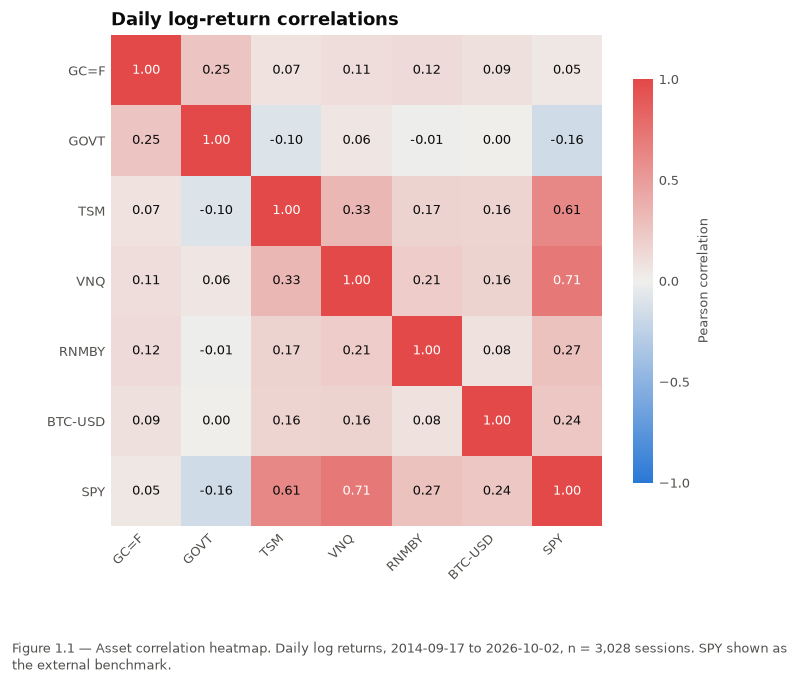

In [12]:
full_panel_returns = returns[("daily", "log")].loc[panel.full_panel_start:]
heatmap_order = cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK]

fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax, correlations = viz.correlation_heatmap(full_panel_returns, heatmap_order, ax=ax)
ax.set_title("Daily log-return correlations")
viz.caption(
    ax,
    f"Figure 1.1 — Asset correlation heatmap. Daily log returns, "
    f"{panel.full_panel_start.date()} to {panel.calendar[-1].date()}, "
    f"n = {len(full_panel_returns.dropna()):,} sessions. SPY shown as the external benchmark.",
)
plt.show()

In [13]:
off_diagonal = correlations.loc[cfg.ASSET_ORDER, cfg.ASSET_ORDER].where(
    ~np.eye(len(cfg.ASSET_ORDER), dtype=bool)
).stack()
print(f"Mean pairwise correlation across the six assets: {off_diagonal.mean():.2f}")
print(f"Highest pair: {off_diagonal.idxmax()} at {off_diagonal.max():.2f}")
print(f"Lowest pair : {off_diagonal.idxmin()} at {off_diagonal.min():.2f}")

Mean pairwise correlation across the six assets: 0.11
Highest pair: ('TSM', 'VNQ') at 0.33
Lowest pair : ('GOVT', 'TSM') at -0.10


The six assets are **genuinely weakly correlated**: the mean pairwise correlation is well under 0.25,
and gold and Treasuries are close to independent of everything equity-like. That is the condition under
which the correlation-aware strategies (GMV, ERC, MDP, MDC) can separate themselves from the ones that
ignore correlation (EW, IV) — if the matrix were uniformly high, all eight would converge and the
comparison would have little to say.

`VNQ`–`SPY` at 0.71 and `TSM`–`SPY` at 0.61 are the two genuine equity-beta exposures in the set.

---

## A8 — Figure 1.2, cumulative growth of $1

Every series rebased to $1 at the first date all six assets have data, on a **log y-axis** so that equal
vertical distances mean equal percentage moves. Without the log scale bitcoin's 185× compresses
everything else onto the axis and the figure says nothing about the other five.

The benchmark is drawn dashed in neutral grey, so it reads as a reference line rather than a seventh
competitor.

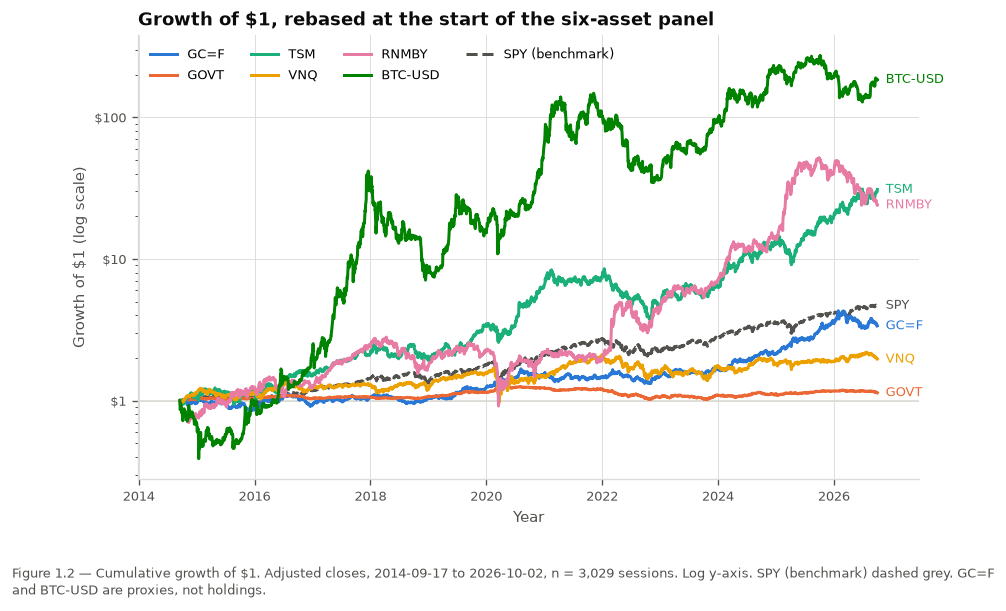

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax, wealth = viz.growth_of_one(panel.prices, cfg.ASSET_ORDER, ax=ax)
ax.set_title("Growth of $1, rebased at the start of the six-asset panel")
viz.caption(
    ax,
    f"Figure 1.2 — Cumulative growth of $1. Adjusted closes, "
    f"{wealth.index[0].date()} to {wealth.index[-1].date()}, n = {len(wealth):,} sessions. "
    "Log y-axis. SPY (benchmark) dashed grey. GC=F and BTC-USD are proxies, not holdings.",
)
plt.show()

In [15]:
terminal = wealth.iloc[-1].rename("Growth of $1").to_frame()
years = (wealth.index[-1] - wealth.index[0]).days / 365.25
terminal["Ann. return %"] = (terminal["Growth of $1"] ** (1 / years) - 1) * 100
terminal["Ann. volatility %"] = (
    np.log(wealth).diff().std() * np.sqrt(cfg.TRADING_DAYS) * 100
)

print(f"Buy-and-hold over the six-asset panel, {years:.1f} years. "
      "Descriptive only -- not a strategy result.")
display(fmt.style(terminal.loc[cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK]], {
    "Growth of $1": lambda v: fmt.number(v, 2),
    "Ann. return %": lambda v: fmt.percent(v, 2),
    "Ann. volatility %": lambda v: fmt.percent(v, 2),
}))

Buy-and-hold over the six-asset panel, 12.0 years. Descriptive only -- not a strategy result.


,Growth of $1,Ann. return %,Ann. volatility %
Ticker,,,
GC=F,3.37,10.62,16.82
GOVT,1.14,1.08,5.05
TSM,30.96,32.99,33.22
VNQ,1.96,5.77,20.17
RNMBY,24.04,30.22,40.86
BTC-USD,184.76,54.26,65.94
SPY,4.70,13.72,17.48


---

## Done-when checks

The plan's exit criteria for workstream A, asserted rather than eyeballed.

In [16]:
checks = []

# 1. No silent fills: every filled cell is accounted for in Table 1.2.
filled_total = sum(panel.fills.values())
reported_total = sum(
    int(quality.loc[t, "Missing obs."]) for t in cfg.ASSET_ORDER
) - sum(
    max(0, int(quality.loc[t, "Missing obs."]) - panel.fills[t]) for t in cfg.ASSET_ORDER
)
checks.append(("No silent fills -- every fill counted in Table 1.2", filled_total == reported_total))

# 2. Pre-entry cells are NaN, not zero- or back-filled.
no_backfill = all(
    panel.prices[t].loc[: panel.prices_raw[t].first_valid_index()].iloc[:-1].isna().all()
    for t in cfg.ASSET_ORDER
)
checks.append(("Pre-entry cells left as NaN", no_backfill))

# 3. Table 1.1 and 1.2 reconcile (asserted in full above).
checks.append(("Tables 1.1 and 1.2 reconcile", set(availability.index) >= set(quality.index)))

# 4. Proxy labels exist for the two proxies and are carried into the prose.
proxies = {t for t, i in cfg.UNIVERSE.items() if i["proxy_for"]}
checks.append(("GC=F and BTC-USD carry proxy labels", proxies == {"GC=F", "BTC-USD"}))

# 5. Both the 15-year span and the 12-year intersection are available to quote.
span = (panel.calendar[-1] - panel.calendar[0]).days / 365.25
intersection = (panel.calendar[-1] - panel.full_panel_start).days / 365.25
checks.append((f"Span {span:.1f}y and intersection {intersection:.1f}y both disclosed",
               round(span, 1) >= 15 and intersection < 15))

for label, passed in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {label}")
assert all(passed for _, passed in checks), "Workstream A exit criteria not met"
print("\nWorkstream A complete.")

[PASS] No silent fills -- every fill counted in Table 1.2
[PASS] Pre-entry cells left as NaN
[PASS] Tables 1.1 and 1.2 reconcile
[PASS] GC=F and BTC-USD carry proxy labels
[PASS] Span 15.0y and intersection 12.0y both disclosed

Workstream A complete.


---

## Handoff

Downstream notebooks rebuild the panel by importing from `src` rather than reading anything this
notebook wrote — there are no data files, by design.

```python
from src import config as cfg, data

close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
returns = data.build_returns(panel)
```

| Object | Used by |
| --- | --- |
| `cfg.UNIVERSE`, `cfg.ASSET_ORDER`, `cfg.ASSET_COLORS` | every notebook |
| `panel.prices` | 03 backtest engine, 05 experiments |
| `panel.risk_free` | 04 strategies (MSR), 06 performance |
| `panel.full_panel_start` | 03, the sampler's availability rule |
| `returns[("daily", "log")]["TSM"]` | 02 stylised facts |
| `cfg.COSTS_BP`, `cfg.SEED`, `cfg.MV_RISK_AVERSION` | 03, 04, 05, 07 |